**Author:** Steve Landry Ndjock

**Version:** 1.0

**Python version:**  3.x

In [ ]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [ ]:
from pathlib import Path
import warnings

### Data Preparation

In [ ]:
from collections import Counter
from collections import defaultdict

In [ ]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [ ]:
df_original = pd.read_csv("cmi_internet.csv")
df = df_WTout.copy()

In [ ]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()

    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()

    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode

    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes

    return df_encode

In [ ]:
df = encoder_labels_categoriques(df)

In [ ]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [ ]:
X.shape

(8460, 83)

In [ ]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5833, 1587,  952,   88]))

**I merge class 2 and 3 into a single class (class 2)**

In [ ]:
# I merge class 2 and 3 into a single class (class 2)
#y = np.where(y == 3, 2, y)

### Data Partitioning

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)

### Balance classes

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [ ]:
import numpy as np
import scipy

scipy.interp = np.interp

In [ ]:
from scikitplot.metrics import plot_roc

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {np.float64(0.0): np.int64(4084), np.float64(1.0): np.int64(4084), np.float64(2.0): np.int64(4084), np.float64(3.0): np.int64(4084)}


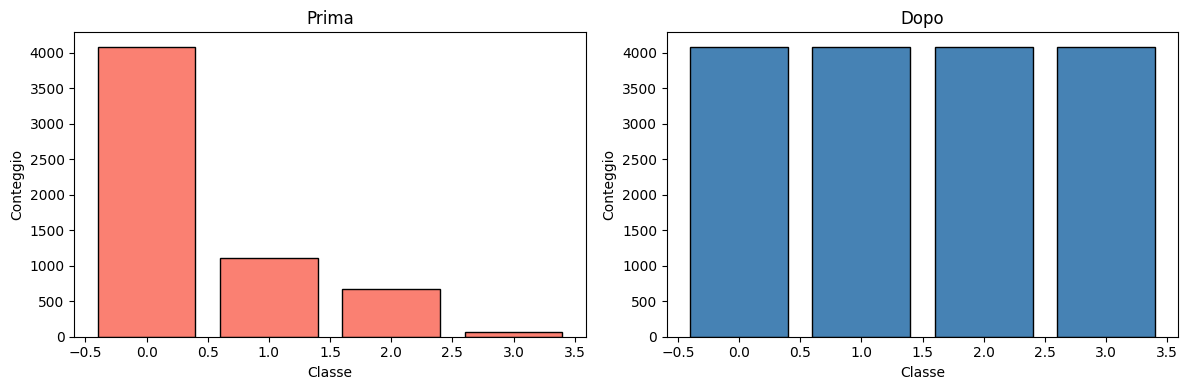

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = Counter(y_train)
after  = Counter(y_train_resampled)

axes[0].bar(before.keys(), before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Conteggio')

axes[1].bar(after.keys(), after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

### Sklearn Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier
hidden_layer_sizes = (100, 200,)

In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 23)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=1000)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6249014972419228
F1-score [0.76833527 0.33544304 0.34210526 0.07142857]
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.77      1749
         1.0       0.34      0.33      0.34       482
         2.0       0.32      0.37      0.34       280
         3.0       0.05      0.11      0.07        27

    accuracy                           0.62      2538
   macro avg       0.37      0.39      0.38      2538
weighted avg       0.64      0.62      0.63      2538



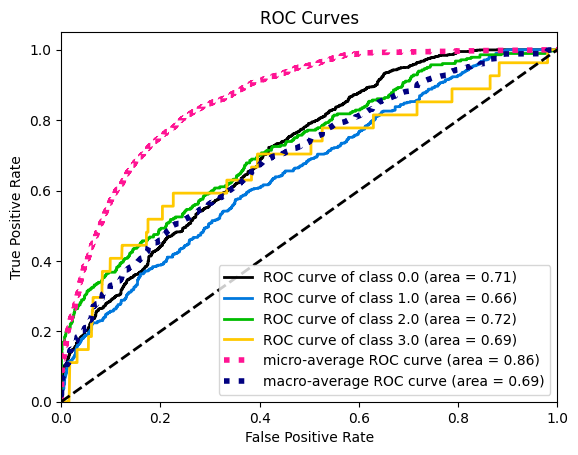

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

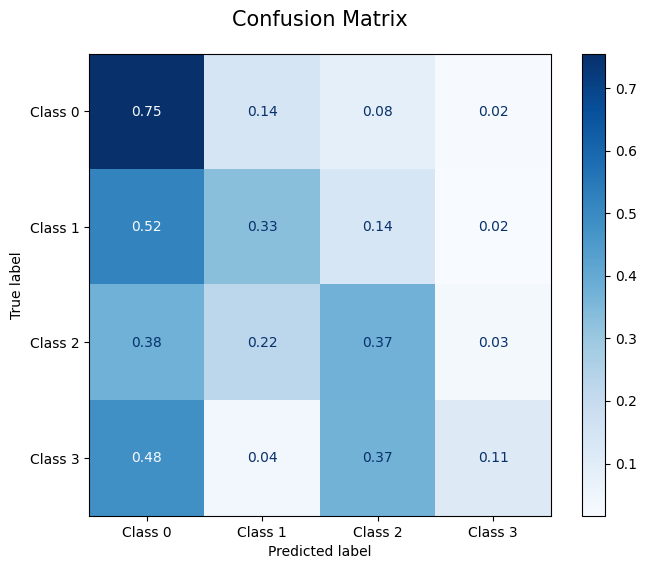

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

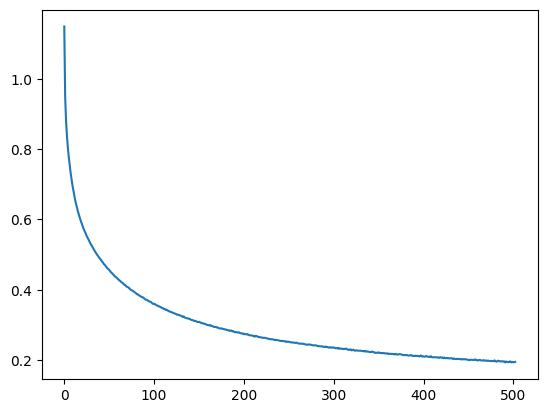

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6296296296296297
F1-score [0.76580588 0.37401575 0.39451115 0.05555556]
              precision    recall  f1-score   support

         0.0       0.80      0.74      0.77      1749
         1.0       0.36      0.39      0.37       482
         2.0       0.38      0.41      0.39       280
         3.0       0.04      0.11      0.06        27

    accuracy                           0.63      2538
   macro avg       0.39      0.41      0.40      2538
weighted avg       0.66      0.63      0.64      2538



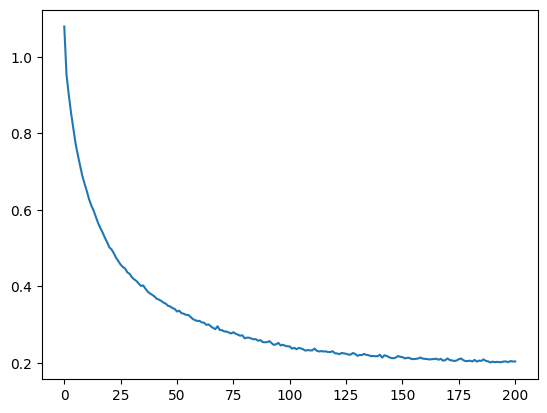

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6185973207249803
F1-score [0.75675676 0.3752495  0.36170213 0.06976744]
              precision    recall  f1-score   support

         0.0       0.80      0.72      0.76      1749
         1.0       0.36      0.39      0.38       482
         2.0       0.31      0.42      0.36       280
         3.0       0.05      0.11      0.07        27

    accuracy                           0.62      2538
   macro avg       0.38      0.41      0.39      2538
weighted avg       0.65      0.62      0.63      2538



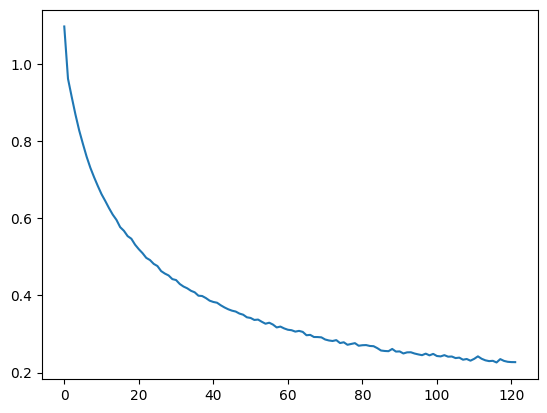

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

#### Gridsearch

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import loguniform
import xgboost as xgb

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_gs = Pipeline([
    ('scaler',   StandardScaler()),
    ('smote',    SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            random_state=42,
            eval_metric='logloss',
        )
    )),
    ('mlp', MLPClassifier(
        random_state=0,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
    ))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64, 32), (256, 128, 64), (128, 64)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__alpha':              [0.01, 0.05, 0.1],
    'mlp__learning_rate_init': [1e-3, 5e-3, 1e-2],
    'mlp__learning_rate':      ['adaptive'],
    'mlp__solver':             ['adam'],
}

grid_search = GridSearchCV(
    estimator=pipeline_gs,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

In [ ]:
print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best F1 (CV) : {grid_search.best_score_:.4f}")

y_pred_gs = grid_search.predict(X_test)
print(f"Accuracy test    : {accuracy_score(y_test, y_pred_gs):.4f}")
print(f"F1 by classe    : {f1_score(y_test, y_pred_gs, average=None)}")
print(classification_report(y_test, y_pred_gs))


#### Randomized search

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import loguniform
import xgboost as xgb

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


pipeline_rs = Pipeline([
    ('scaler',   StandardScaler()),
    ('smote',    SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            n_estimators=50,
            n_jobs=1,
            random_state=42,
            eval_metric='logloss',
        )
    )),
    ('mlp', MLPClassifier(
        random_state=0,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
    ))
])

param_dist = {
    'mlp__hidden_layer_sizes': [
        (64,), (128,),
        (128, 64), (256, 128),
        (128, 64, 32), (256, 128, 64),
        (64, 32, 16),
    ],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__alpha':              loguniform(1e-4, 1e0),
    'mlp__learning_rate':      ['constant', 'adaptive'],
    'mlp__learning_rate_init': loguniform(1e-4, 1e-1),
    'mlp__momentum':           [0.85, 0.9, 0.95],
    'mlp__solver':             ['adam', 'sgd'],
    'mlp__batch_size':         [32, 64, 128, 'auto'],
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rs,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    pre_dispatch='2*n_jobs',
    return_train_score=True,
)

random_search.fit(X_train, y_train)

In [ ]:
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best F1 (CV) : {random_search.best_score_:.4f}")

y_pred_rs = random_search.predict(X_test)
print(f"Accuracy test    : {accuracy_score(y_test, y_pred_rs):.4f}")
print(f"F1 by class   : {f1_score(y_test, y_pred_rs, average=None)}")
print(classification_report(y_test, y_pred_rs))

 ### New target variable data preparation

**Basic_Demos-Sex**

In [ ]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0


In [ ]:
df_NN = df.copy()

In [ ]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [ ]:
X = df.values
y = np.array(df_NN['Basic_Demos-Sex'])

In [ ]:
print("Distribuzione classi:", Counter(y))

Distribuzione classi: Counter({0.0: 5056, 1.0: 3404})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7078 samples
Distribution of classes after SMOTE : {0.0: 3539, 1.0: 3539}


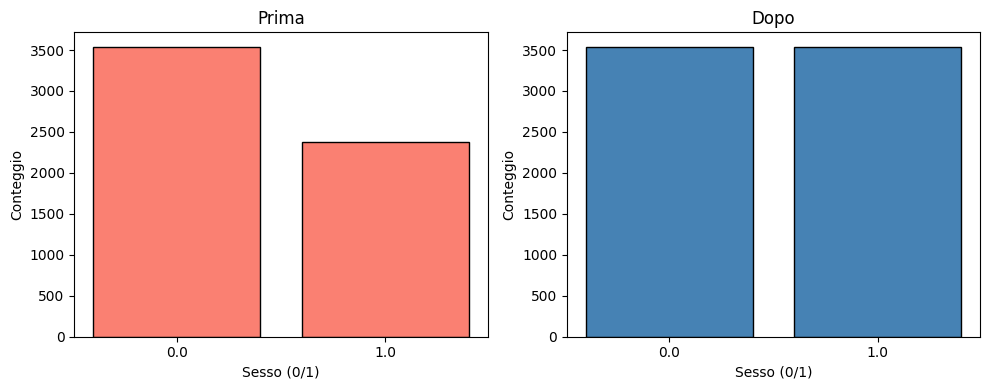

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = Counter(y_train)
after  = Counter(y_train_resampled)

axes[0].bar([str(k) for k in before.keys()], before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Sesso (0/1)')
axes[0].set_ylabel('Conteggio')

axes[1].bar([str(k) for k in after.keys()], after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Sesso (0/1)')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7078, 23)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=1000)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6883372734436565
F1-score [0.73304084 0.62565073]
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.73      1517
         1.0       0.61      0.65      0.63      1021

    accuracy                           0.69      2538
   macro avg       0.68      0.68      0.68      2538
weighted avg       0.69      0.69      0.69      2538



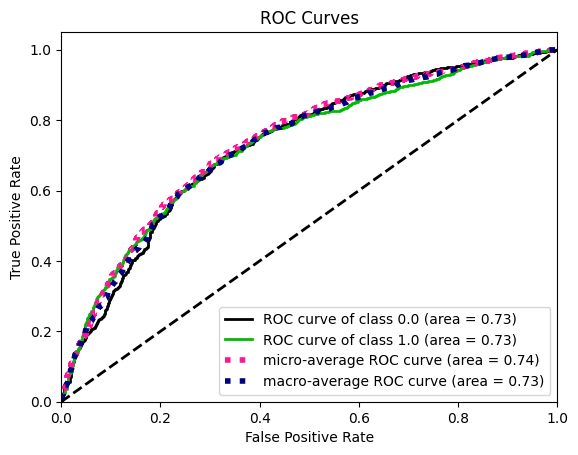

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

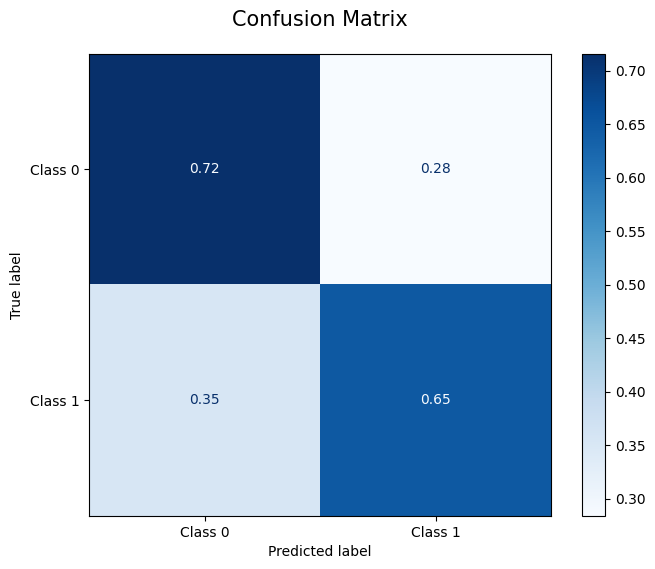

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

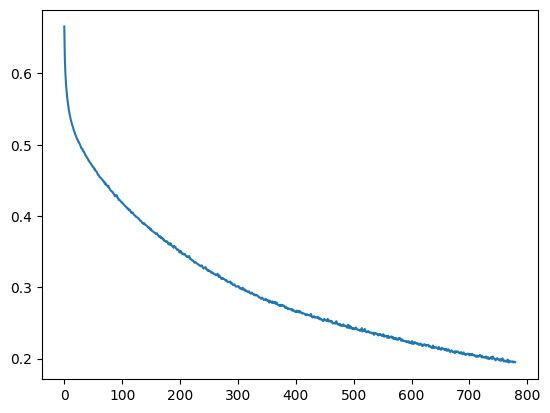

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6804570527974784
F1-score [0.72830821 0.6121473 ]
              precision    recall  f1-score   support

         0.0       0.74      0.72      0.73      1517
         1.0       0.60      0.63      0.61      1021

    accuracy                           0.68      2538
   macro avg       0.67      0.67      0.67      2538
weighted avg       0.68      0.68      0.68      2538



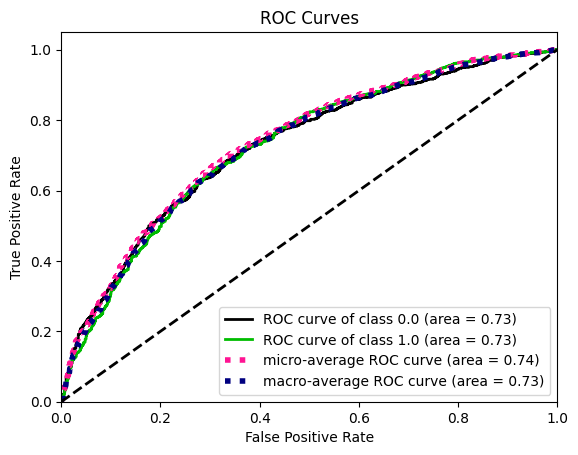

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

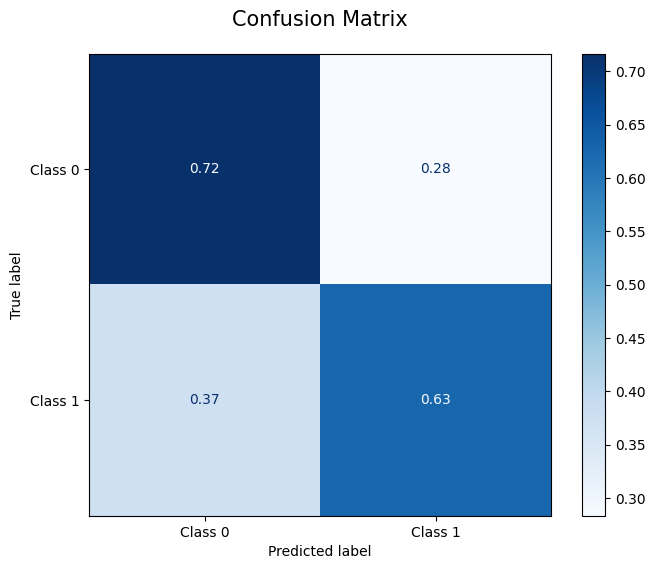

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

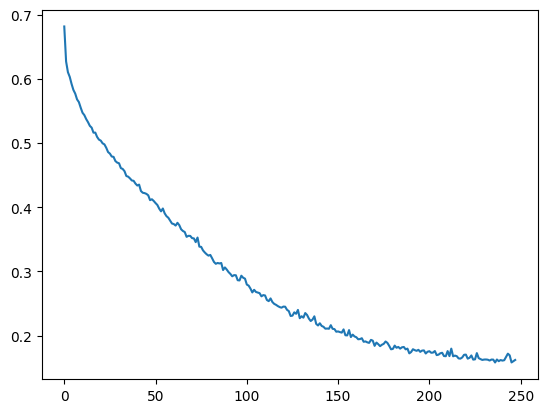

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7265563435776202
F1-score [0.75546159 0.6899017 ]
              precision    recall  f1-score   support

         0.0       0.81      0.71      0.76      1517
         1.0       0.63      0.76      0.69      1021

    accuracy                           0.73      2538
   macro avg       0.72      0.73      0.72      2538
weighted avg       0.74      0.73      0.73      2538



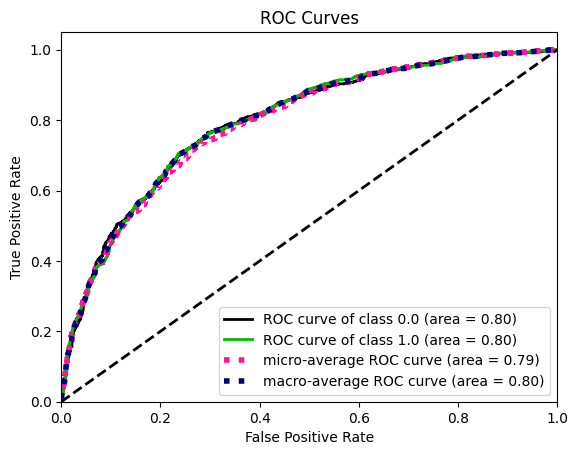

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

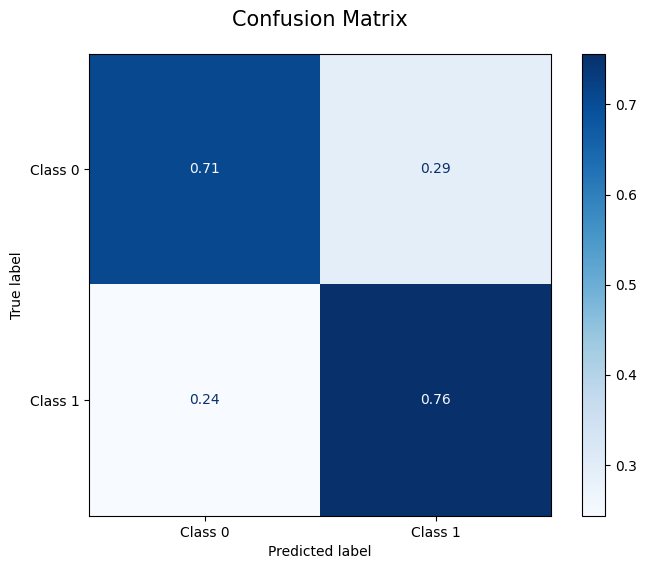

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

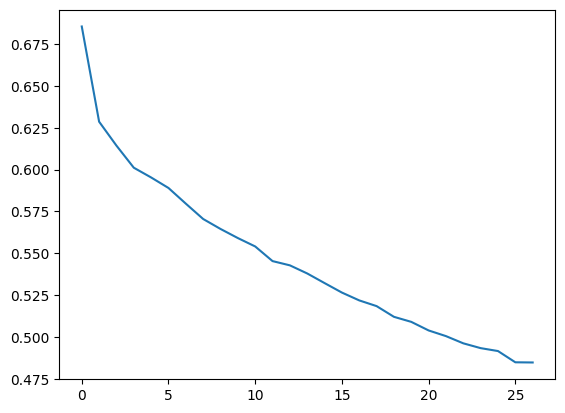

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

**Basic_Demos-Enroll_Season**

In [ ]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0


In [ ]:
df_NN = df.copy()

In [ ]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [ ]:
X = df.values
y = np.array(df_NN['Basic_Demos-Enroll_Season'])

In [ ]:
ctr = Counter(y)
ctr

Counter({0: 1838, 2: 2002, 3: 2173, 1: 2447})

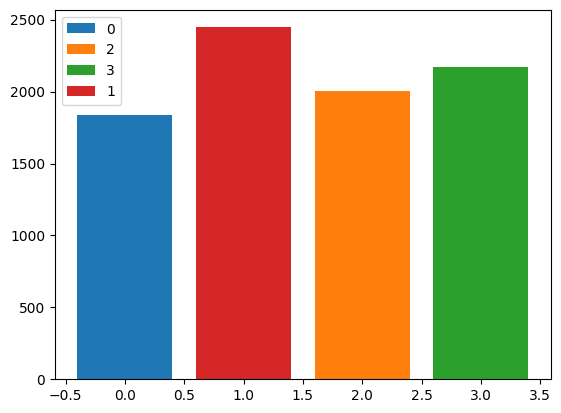

In [ ]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [ ]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0, 2.0, 3.0]
    colors  = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']  # Verde, Rosso, Blu, Arancione

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6852 samples
Distribution of classes after SMOTE : {0: 1713, 1: 1713, 2: 1713, 3: 1713}


In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6852, 7)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=1000)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8191489361702128
F1-score [0.83962264 0.81662269 0.79188713 0.82869693]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       537
           1       0.79      0.84      0.82       734
           2       0.78      0.80      0.79       562
           3       0.86      0.80      0.83       705

    accuracy                           0.82      2538
   macro avg       0.82      0.82      0.82      2538
weighted avg       0.82      0.82      0.82      2538



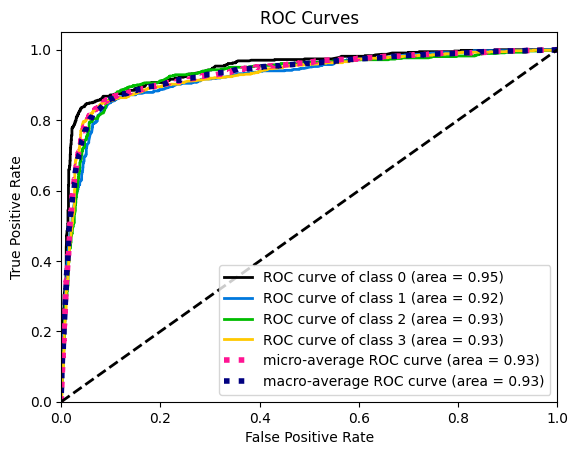

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

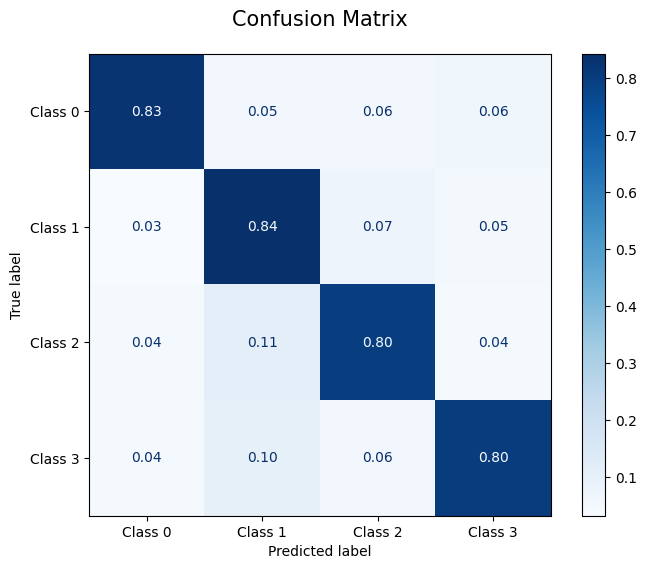

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

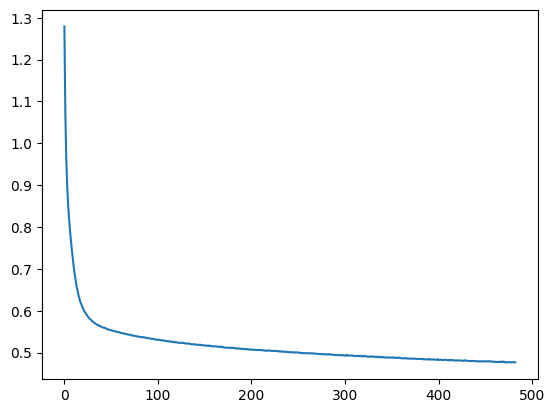

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8006304176516943
F1-score [0.81226766 0.80974325 0.77288732 0.80446097]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       537
           1       0.78      0.84      0.81       734
           2       0.76      0.78      0.77       562
           3       0.85      0.77      0.80       705

    accuracy                           0.80      2538
   macro avg       0.80      0.80      0.80      2538
weighted avg       0.80      0.80      0.80      2538



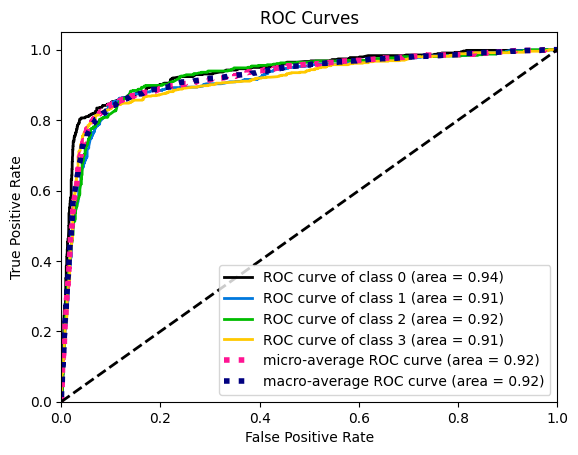

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

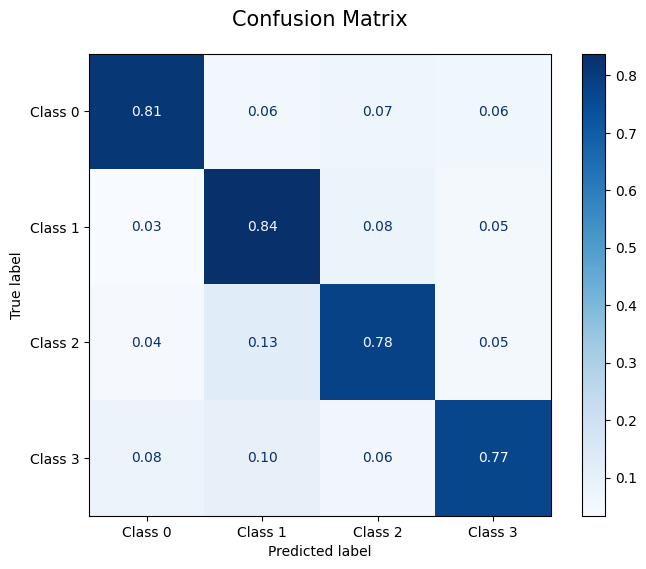

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

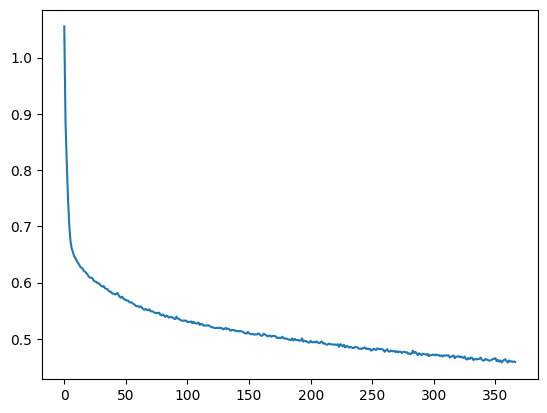

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8238770685579196
F1-score [0.83877159 0.81824104 0.80530973 0.83418554]
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       537
           1       0.78      0.86      0.82       734
           2       0.80      0.81      0.81       562
           3       0.86      0.81      0.83       705

    accuracy                           0.82      2538
   macro avg       0.83      0.82      0.82      2538
weighted avg       0.83      0.82      0.82      2538



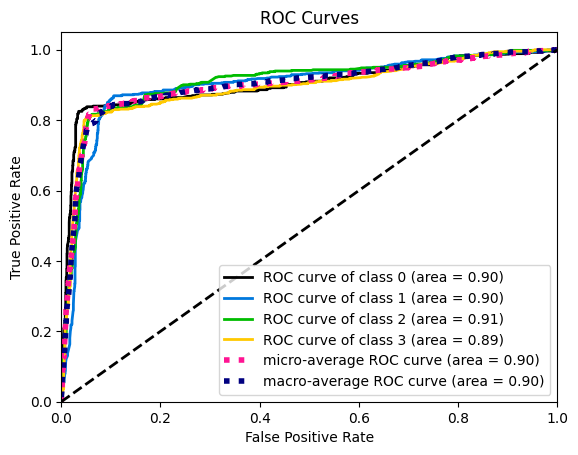

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

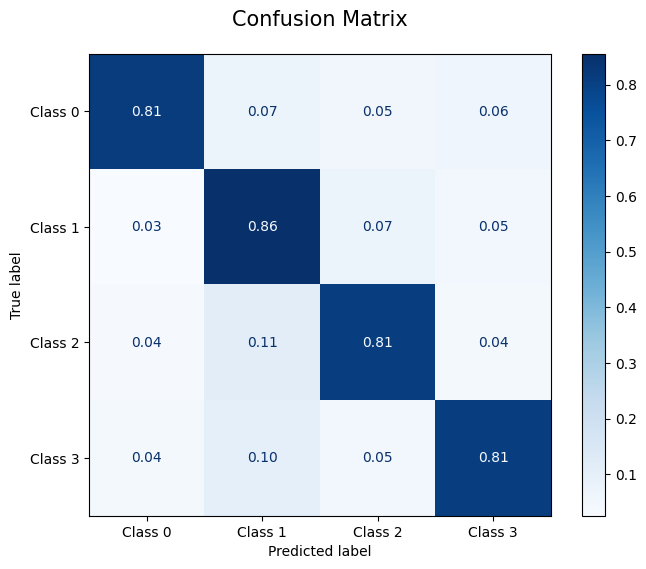

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

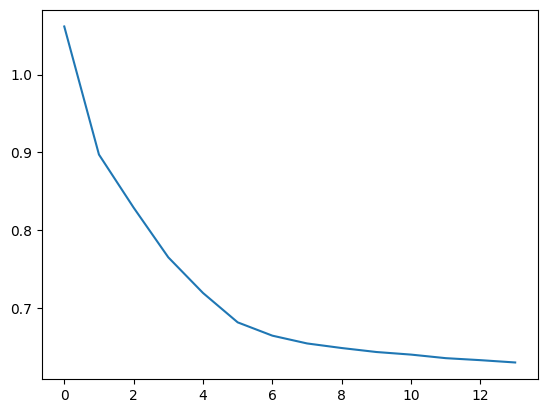

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

### Keras

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
n_classes = 4
def build_model():
    n_feature = X_train_sel.shape[1]

    model = Sequential()
    model.add(Input(shape=(n_feature,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer="adam", metrics=['accuracy'])
    return model

In [ ]:
model1 = build_model()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,588 (45.27 KB)

 Trainable params: 11,588 (45.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(X_train_sel, y_train_resampled, epochs=200, batch_size=32).history

Epoch 1/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6315 - loss: 0.8778
Epoch 2/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7150 - loss: 0.6963
Epoch 3/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7565 - loss: 0.6107
Epoch 4/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7806 - loss: 0.5585
Epoch 5/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8011 - loss: 0.5133
Epoch 6/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8112 - loss: 0.4823
Epoch 7/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8266 - loss: 0.4455
Epoch 8/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8439 - loss: 0.4167
Epoch 9/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3909
Epoch 10/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8628 - loss: 0.3677
Epoch 11/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8693 - loss: 0.3492
Epoch 12/200
511/511 ━━━━━━━━━━━━━━━━━━━━

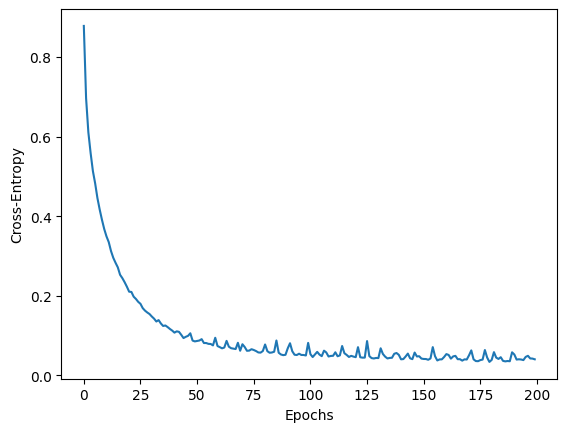

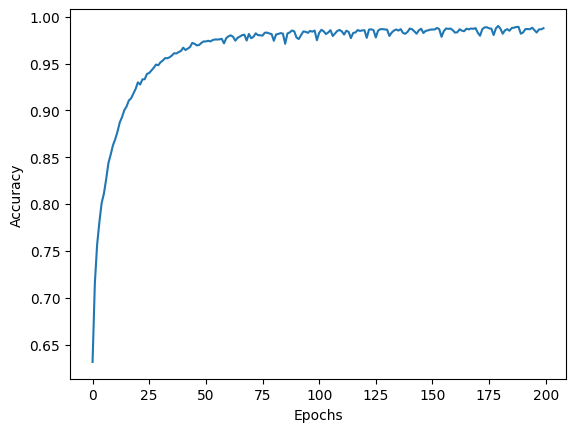

In [ ]:
plt.plot(history1['loss'])
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.show()
plt.plot(history1['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
test_loss_1, test_acc_1 = model1.evaluate(X_test_sel, y_test)
print('Loss %f, Accuracy %f' % (test_loss_1, test_acc_1))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6454 - loss: 4.9672
Loss 4.967203, Accuracy 0.645390


### Sklearn Wrapper
wraps a keras model in a sklearn-like object

In [ ]:
!pip install "scikeras>=0.13.0" "scikit-learn>=1.4,<1.6"

In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6328 - loss: 0.8726
Epoch 2/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7183 - loss: 0.6815
Epoch 3/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7496 - loss: 0.6062
Epoch 4/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7761 - loss: 0.5515
Epoch 5/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8001 - loss: 0.5046
Epoch 6/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8137 - loss: 0.4697
Epoch 7/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8298 - loss: 0.4421
Epoch 8/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.4160
Epoch 9/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.3894
Epoch 10/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3740
Epoch 11/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8670 - loss: 0.3505
Epoch 12/200
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7c0d98fae7a0>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
clf.model_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,766 (135.81 KB)

 Trainable params: 11,588 (45.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,178 (90.54 KB)

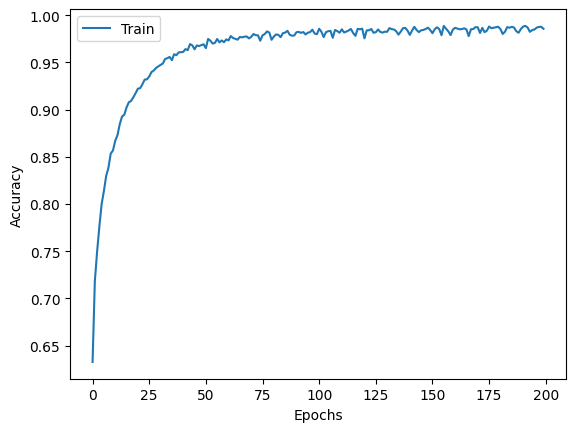

In [ ]:
history = clf.history_
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

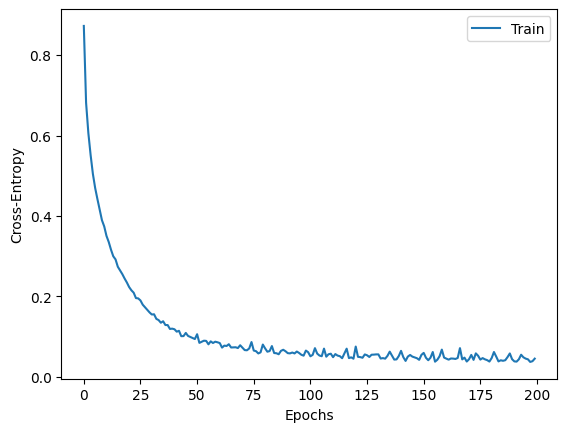

In [ ]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.6713947990543735
F1-score [0.80320177 0.33144154 0.3976834  0.        ]
              precision    recall  f1-score   support

         0.0       0.78      0.83      0.80      1749
         1.0       0.37      0.30      0.33       482
         2.0       0.43      0.37      0.40       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.67      2538
   macro avg       0.39      0.38      0.38      2538
weighted avg       0.65      0.67      0.66      2538



In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=1000)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5891 - loss: 0.9228 - val_accuracy: 0.5820 - val_loss: 1.1160
Epoch 2/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6631 - loss: 0.7829 - val_accuracy: 0.7509 - val_loss: 0.7881
Epoch 3/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6984 - loss: 0.7200 - val_accuracy: 0.6741 - val_loss: 0.8877
Epoch 4/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7238 - loss: 0.6660 - val_accuracy: 0.7289 - val_loss: 0.7805
Epoch 5/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7478 - loss: 0.6210 - val_accuracy: 0.7154 - val_loss: 0.7726
Epoch 6/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7645 - loss: 0.5785 - val_accuracy: 0.7319 - val_loss: 0.7394
Epoch 7/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7858 - loss: 0.5403 - val_accuracy: 0.8767 - val_loss: 0.4423
Epoch 8/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8052 - loss: 0.5018 - val_accuracy:

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7c0d98fae7a0>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.656816390858944
F1-score [0.79007416 0.35876289 0.38779174 0.        ]
              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79      1749
         1.0       0.36      0.36      0.36       482
         2.0       0.39      0.39      0.39       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.66      2538
   macro avg       0.38      0.38      0.38      2538
weighted avg       0.65      0.66      0.66      2538



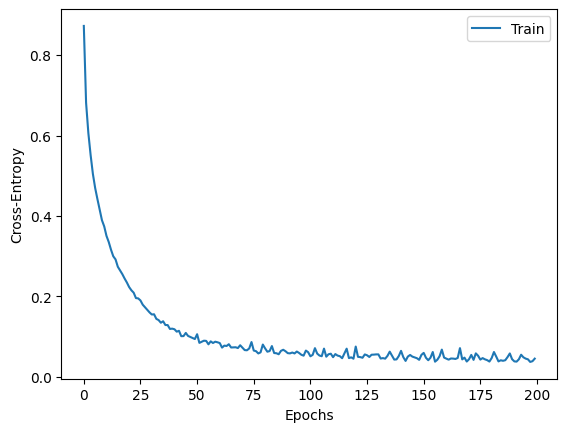

In [ ]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

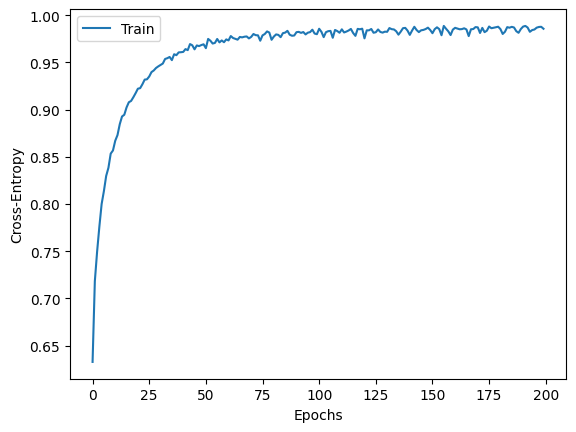

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

### Early stopping

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
es = EarlyStopping(monitor='val_accuracy', patience=50, verbose=True)
mc = ModelCheckpoint('best_model_NOREG.keras', monitor='val_accuracy', save_best_only=True)

clf = KerasClassifier(build_model, callbacks=[es, mc])

In [ ]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5864 - loss: 0.9336 - val_accuracy: 0.5040 - val_loss: 1.2417
Epoch 2/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6579 - loss: 0.7922 - val_accuracy: 0.5985 - val_loss: 1.1243
Epoch 3/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6959 - loss: 0.7250 - val_accuracy: 0.7041 - val_loss: 0.7909
Epoch 4/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7242 - loss: 0.6660 - val_accuracy: 0.7509 - val_loss: 0.6939
Epoch 5/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7483 - loss: 0.6167 - val_accuracy: 0.9082 - val_loss: 0.3903
Epoch 6/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7747 - loss: 0.5731 - val_accuracy: 0.8464 - val_loss: 0.5152
Epoch 7/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7881 - loss: 0.5371 - val_accuracy: 0.7895 - val_loss: 0.5688
Epoch 8/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8058 - loss: 0.5023 - val_accu

KerasClassifier(
	model=<function build_model at 0x7c0d98fae7a0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d8c3bab40>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0d8c52dac0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.6347517730496454
F1-score [0.77522536 0.34943474 0.35236542 0.        ]
              precision    recall  f1-score   support

         0.0       0.79      0.76      0.78      1749
         1.0       0.35      0.35      0.35       482
         2.0       0.32      0.39      0.35       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.63      2538
   macro avg       0.36      0.38      0.37      2538
weighted avg       0.65      0.63      0.64      2538



80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


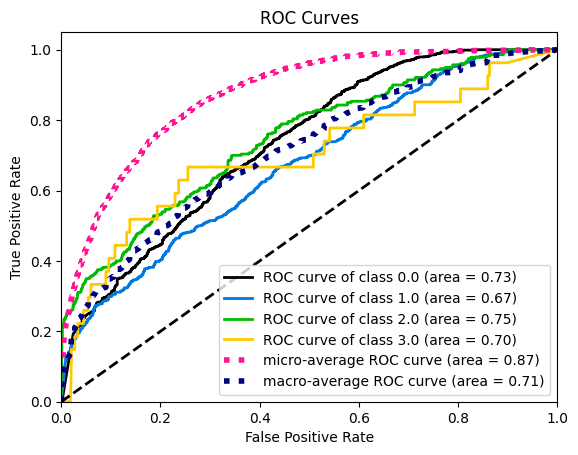

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

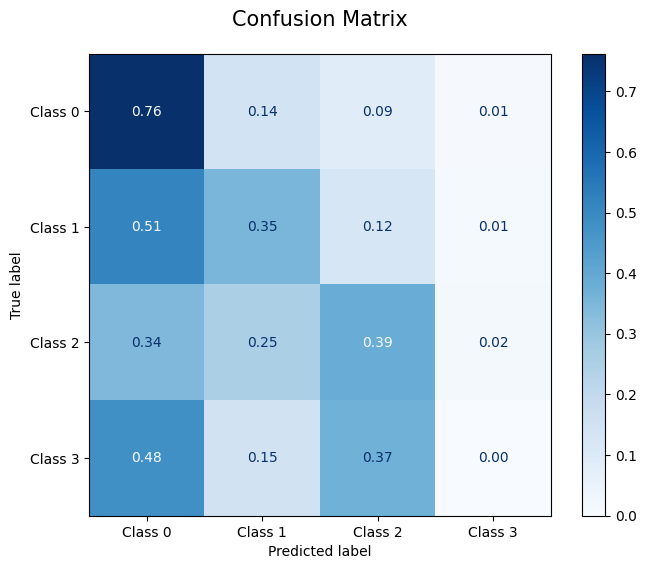

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### L2 Regularization

In [ ]:
from keras.regularizers import l2, l1

def build_L2_model():
    model = Sequential()

    n_feature = X_train_sel.shape[1]
    h_dim=100
    model.add(Dense(h_dim, activation='relu',
                    input_shape=(n_feature,), kernel_regularizer=l2(0.001)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(n_classes))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:
mc = ModelCheckpoint('best_model_L2.keras', monitor='val_accuracy', save_best_only=True)

L2_model = KerasClassifier(build_L2_model, callbacks=[es,mc])
L2_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5245 - loss: 1.2105 - val_accuracy: 0.5725 - val_loss: 2.8851
Epoch 2/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5253 - loss: 1.0821 - val_accuracy: 0.3849 - val_loss: 2.9949
Epoch 3/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5165 - loss: 1.0622 - val_accuracy: 0.0688 - val_loss: 2.0021
Epoch 4/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3600 - loss: 1.0943 - val_accuracy: 0.7840 - val_loss: 1.3046
Epoch 5/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4040 - loss: 1.1726 - val_accuracy: 0.0000e+00 - val_loss: 2.1675
Epoch 6/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4125 - loss: 1.1683 - val_accuracy: 0.0000e+00 - val_loss: 1.9333
Epoch 7/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3641 - loss: 1.1552 - val_accuracy: 0.0000e+00 - val_loss: 1.8342
Epoch 8/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3525 - loss: 1.1614 - val_accu

KerasClassifier(
	model=<function build_L2_model at 0x7c0d8c7a1080>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d8c3bab40>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0d8c5e59a0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

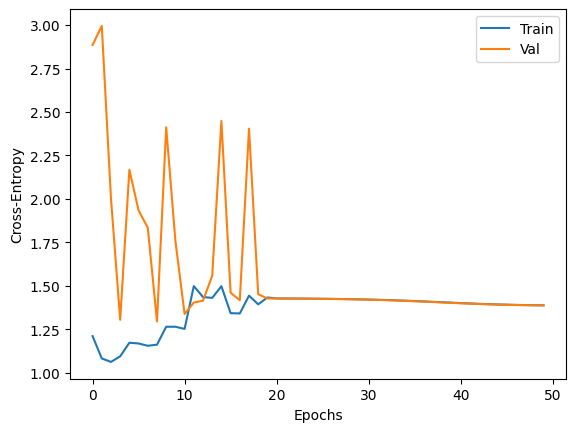

In [ ]:
history = L2_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

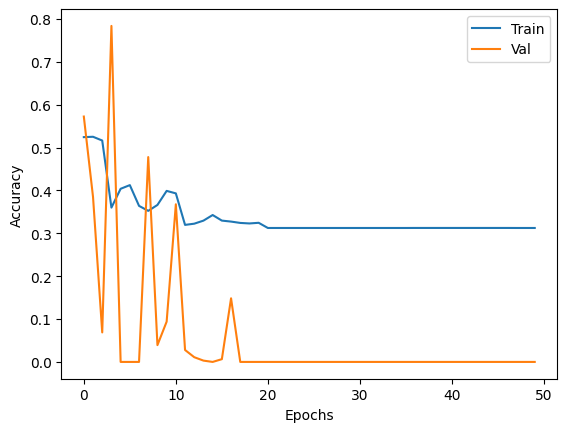

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Dropout

In [ ]:
from keras.layers import Dropout

def build_DROPOUT_model(meta):
    # define the model
    model = Sequential()

    n_feature = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    h_dim = 100
    model.add(Dense(h_dim, activation='relu', input_shape=(n_feature,)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(h_dim, activation='relu'))
    #linear activation
    model.add(Dense(n_classes, activation='softmax')) # Added activation for multiclass

    #compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

mc = ModelCheckpoint('best_model_DROPOUT.keras', monitor='val_accuracy', save_best_only=True)

DROPOUT_model = KerasClassifier(build_DROPOUT_model, callbacks=[es,mc])
DROPOUT_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5775 - loss: 0.9234 - val_accuracy: 0.7090 - val_loss: 0.9225
Epoch 2/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6811 - loss: 0.7430 - val_accuracy: 0.8479 - val_loss: 0.5020
Epoch 3/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7296 - loss: 0.6407 - val_accuracy: 0.7922 - val_loss: 0.5721
Epoch 4/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7742 - loss: 0.5621 - val_accuracy: 0.8247 - val_loss: 0.4861
Epoch 5/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8049 - loss: 0.4859 - val_accuracy: 0.9722 - val_loss: 0.2189
Epoch 6/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.4309 - val_accuracy: 0.8761 - val_loss: 0.7219
Epoch 7/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8501 - loss: 0.3874 - val_accuracy: 0.9538 - val_loss: 0.1861
Epoch 8/500
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3529 - val_accuracy: 0.9327

KerasClassifier(
	model=<function build_DROPOUT_model at 0x7c0d6d350360>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d8c3bab40>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0d98f97590>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

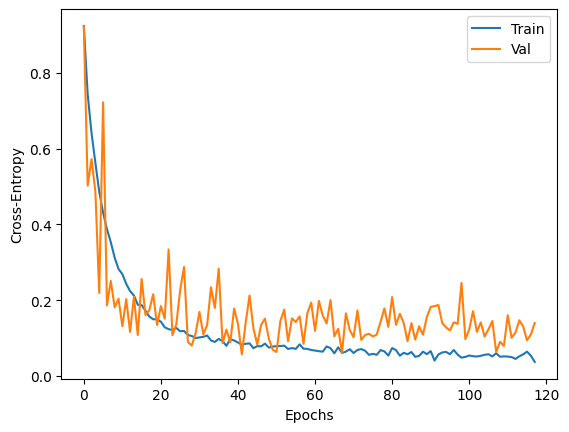

In [ ]:
history = DROPOUT_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

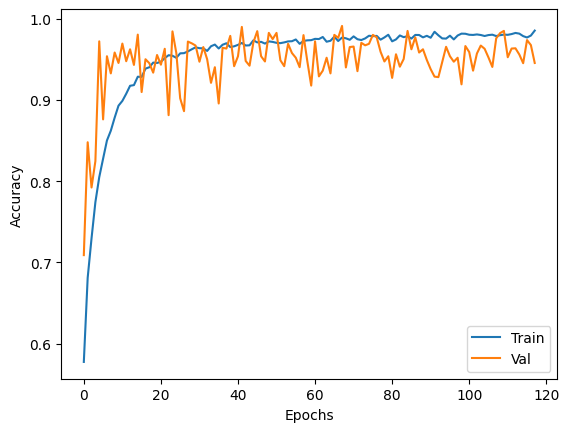

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Model Comparison

In [ ]:
# laod best models and test them
from keras.models import load_model

best_NOREG_model = load_model('best_model_NOREG.keras')
best_L2_model = load_model('best_model_L2.keras')
best_DROPOUT_model = load_model('best_model_DROPOUT.keras')

loss_NOREG, acc_NOREG = best_NOREG_model.evaluate(X_test_sel, y_test)
loss_L2, acc_L2 = best_L2_model.evaluate(X_test_sel, y_test)
loss_DROPOUT, acc_DROPOUT = best_DROPOUT_model.evaluate(X_test_sel, y_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6545 - loss: 1.5952
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6292 - loss: 1.1080
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6533 - loss: 3.5683


In [ ]:
print('Loss %f, Accuracy %f' % (loss_NOREG, acc_NOREG))
print('Loss %f, Accuracy %f' % (loss_L2, acc_L2))
print('Loss %f, Accuracy %f' % (loss_DROPOUT, acc_DROPOUT))

Loss 1.595218, Accuracy 0.654452
Loss 1.108049, Accuracy 0.629236
Loss 3.568297, Accuracy 0.653270


#### Hyper-Parameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
def build_model(meta, hidden_layer_sizes, activation):
    n_features_in_ = meta["n_features_in_"]
    n_classes_ = meta["n_classes_"]
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(n_features_in_,)))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(keras.layers.Dense(hidden_layer_size, activation=activation))
    model.add(keras.layers.Dense(n_classes_, activation="softmax"))
    return model

In [ ]:
clf = KerasClassifier(
    model=build_model,
    loss="sparse_categorical_crossentropy",
    verbose=False
)

In [ ]:
params = {
    'optimizer__learning_rate': [0.001, 0.01, 0.1, 1],
    'model__hidden_layer_sizes': [(100, 100, 100), (50, 50, 50), (10, 10, 10),
                                  (100, 50, 10), (10, 10, 10), (10, 10)],
    'model__activation': ['relu', 'tanh'],
    'optimizer': ["adam", "sgd"],
    'epochs': [10, 50, 100, 200]
}

gs = RandomizedSearchCV(clf, params, scoring='accuracy', verbose=True, n_iter=15, cv=3)

In [ ]:
from tensorflow import keras

In [ ]:
gs.fit(X_train_sel, y_train_resampled)

In [ ]:
print(gs.best_score_, gs.best_params_)

0.8409657959085396 {'optimizer__learning_rate': 0.001, 'optimizer': 'adam', 'model__hidden_layer_sizes': (50, 50, 50), 'model__activation': 'tanh', 'epochs': 50}


In [ ]:
y_pred = gs.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5969267139479906
F1-score [0.73677812 0.34733894 0.36018957 0.07317073]
              precision    recall  f1-score   support

         0.0       0.79      0.69      0.74      1749
         1.0       0.32      0.39      0.35       482
         2.0       0.32      0.41      0.36       280
         3.0       0.05      0.11      0.07        27

    accuracy                           0.60      2538
   macro avg       0.37      0.40      0.38      2538
weighted avg       0.64      0.60      0.61      2538



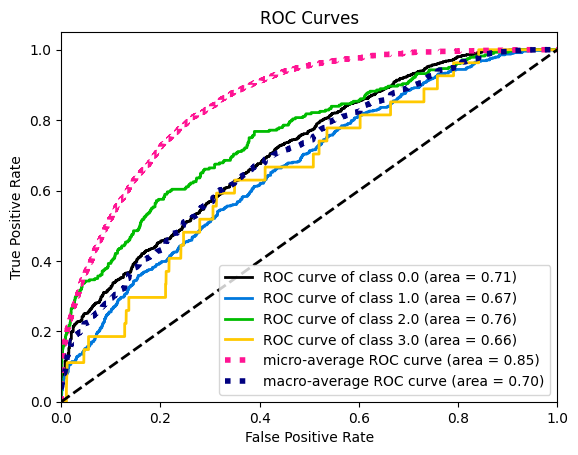

In [ ]:
y_score = gs.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

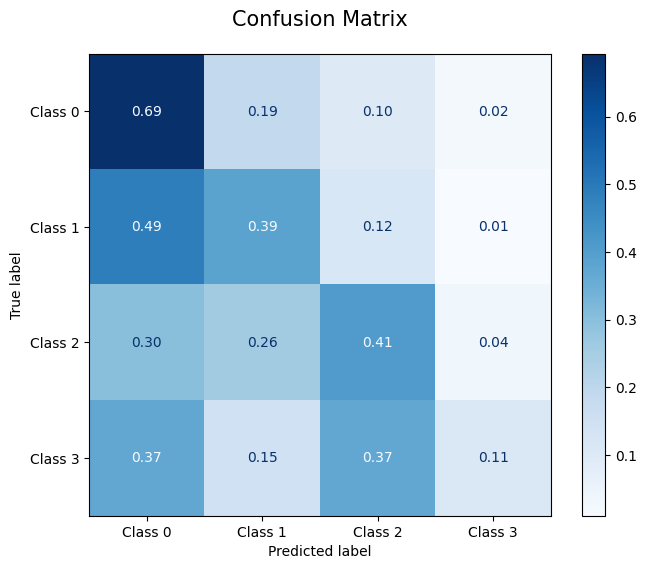

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# New target variable

**Basic_Demos-Enroll_Season**

In [ ]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0


In [ ]:
df_Keras = df.copy()

In [ ]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [ ]:
X = df.values
y = np.array(df_Keras['Basic_Demos-Enroll_Season'])

In [ ]:
ctr = Counter(y)
ctr

Counter({np.int8(0): 1838,
         np.int8(2): 2002,
         np.int8(3): 2173,
         np.int8(1): 2447})

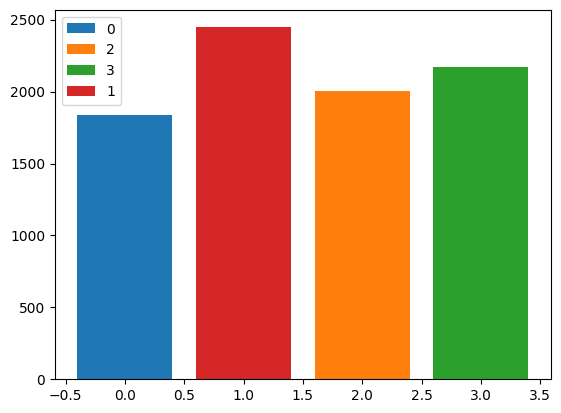

In [ ]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6852 samples
Distribution of classes after SMOTE : {np.int8(0): np.int64(1713), np.int8(1): np.int64(1713), np.int8(2): np.int64(1713), np.int8(3): np.int64(1713)}


In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6852, 10)

In [ ]:
n_classes = 4
def build_model():
    n_feature = X_train_sel.shape[1]

    model = Sequential()
    model.add(Input(shape=(n_feature,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer="adam", metrics=['accuracy'])
    return model

In [ ]:
model1 = build_model()
model1.summary()

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_197 (Dense)               │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_198 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_199 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,924 (38.77 KB)

 Trainable params: 9,924 (38.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(X_train_sel, y_train_resampled, epochs=200, batch_size=32).history

Epoch 1/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6553 - loss: 0.9426
Epoch 2/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - loss: 0.7019
Epoch 3/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8201 - loss: 0.6236
Epoch 4/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8252 - loss: 0.5906
Epoch 5/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8252 - loss: 0.5726
Epoch 6/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8275 - loss: 0.5596
Epoch 7/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8268 - loss: 0.5469
Epoch 8/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 0.5379
Epoch 9/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8304 - loss: 0.5292
Epoch 10/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8322 - loss: 0.5233
Epoch 11/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8295 - loss: 0.5179
Epoch 12/200
215/215 ━━━━━━━━━━━━━━━━━━━━

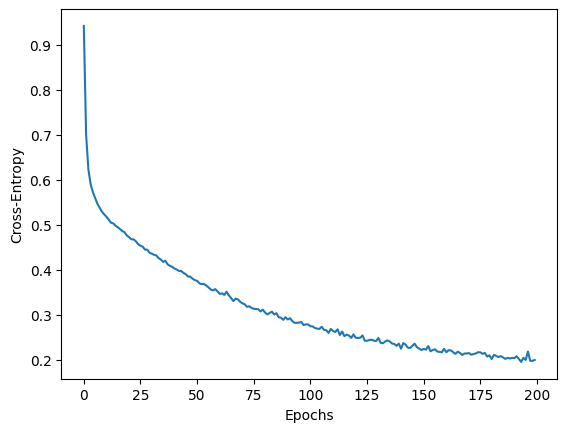

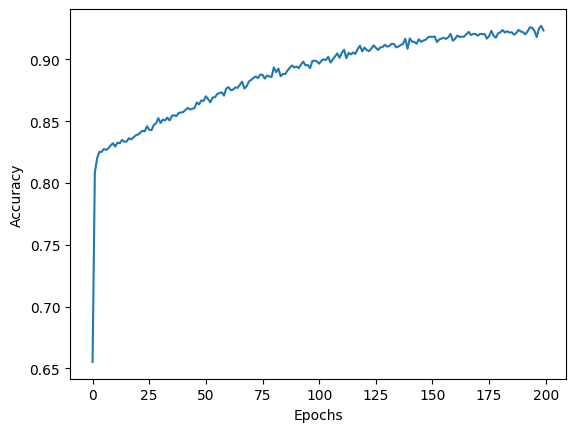

In [ ]:
plt.plot(history1['loss'])
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.show()
plt.plot(history1['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
test_loss_1, test_acc_1 = model1.evaluate(X_test_sel, y_test)
print('Loss %f, Accuracy %f' % (test_loss_1, test_acc_1))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7545 - loss: 1.3216
Loss 1.321619, Accuracy 0.754531


### Sklearn Wrapper
wraps a keras model in a sklearn-like object

In [ ]:
!pip install "scikeras>=0.13.0" "scikit-learn>=1.4,<1.6"

In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6677 - loss: 0.9381
Epoch 2/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8056 - loss: 0.6902
Epoch 3/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8208 - loss: 0.6190
Epoch 4/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8249 - loss: 0.5876
Epoch 5/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8256 - loss: 0.5681
Epoch 6/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8257 - loss: 0.5577
Epoch 7/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8279 - loss: 0.5470
Epoch 8/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8271 - loss: 0.5408
Epoch 9/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8301 - loss: 0.5335
Epoch 10/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.5245
Epoch 11/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8290 - loss: 0.5227
Epoch 12/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7c0d60f13ba0>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
clf.model_.summary()

Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_200 (Dense)               │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_201 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_202 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,774 (116.31 KB)

 Trainable params: 9,924 (38.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,850 (77.54 KB)

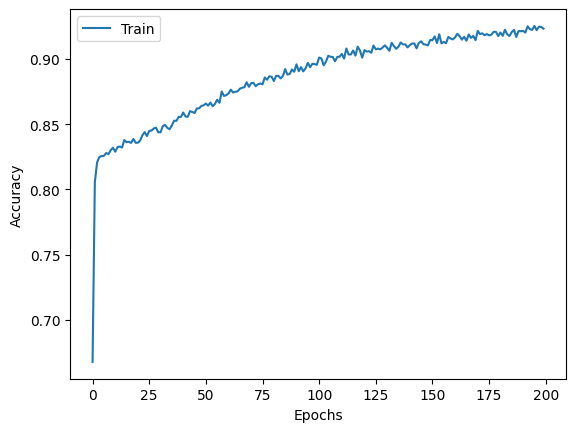

In [ ]:
history = clf.history_
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

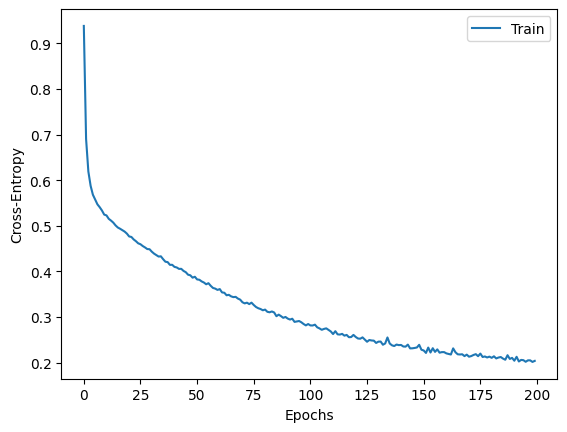

In [ ]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.7624113475177305
F1-score [0.76657061 0.76912752 0.72131148 0.78643579]
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       537
           1       0.76      0.78      0.77       734
           2       0.70      0.74      0.72       562
           3       0.80      0.77      0.79       705

    accuracy                           0.76      2538
   macro avg       0.76      0.76      0.76      2538
weighted avg       0.76      0.76      0.76      2538



In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=1000)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6386 - loss: 1.0035 - val_accuracy: 0.7666 - val_loss: 0.7552
Epoch 2/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7988 - loss: 0.7455 - val_accuracy: 0.7943 - val_loss: 0.6727
Epoch 3/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8225 - loss: 0.6478 - val_accuracy: 0.7994 - val_loss: 0.6103
Epoch 4/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8259 - loss: 0.6074 - val_accuracy: 0.7958 - val_loss: 0.6220
Epoch 5/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8289 - loss: 0.5861 - val_accuracy: 0.7994 - val_loss: 0.5907
Epoch 6/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8303 - loss: 0.5711 - val_accuracy: 0.7950 - val_loss: 0.6115
Epoch 7/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8332 - loss: 0.5594 - val_accuracy: 0.8089 - val_loss: 0.5497
Epoch 8/1000
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8307 - loss: 0.5475 - val_accuracy:

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7c0d60f13ba0>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.768715524034673
F1-score [0.7857829  0.76739563 0.73087309 0.78727915]
              precision    recall  f1-score   support

           0       0.81      0.76      0.79       537
           1       0.75      0.79      0.77       734
           2       0.74      0.72      0.73       562
           3       0.78      0.79      0.79       705

    accuracy                           0.77      2538
   macro avg       0.77      0.77      0.77      2538
weighted avg       0.77      0.77      0.77      2538



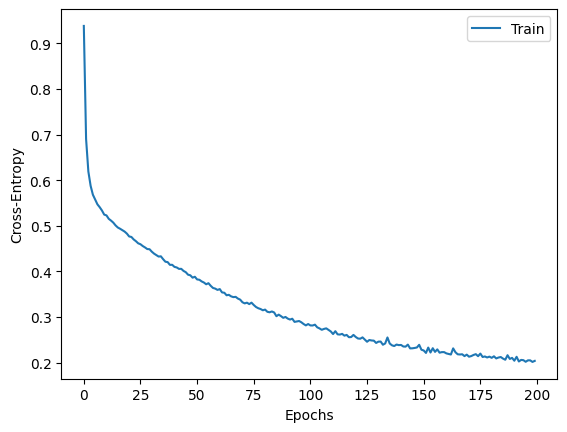

In [ ]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

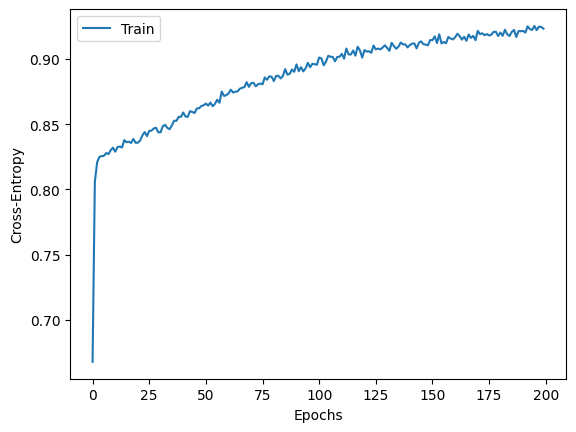

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

### Early stopping

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
es = EarlyStopping(monitor='val_accuracy', patience=50, verbose=True)
mc = ModelCheckpoint('best_model_NOREG.keras', monitor='val_accuracy', save_best_only=True)

clf = KerasClassifier(build_model, callbacks=[es, mc])

In [ ]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6305 - loss: 0.9984 - val_accuracy: 0.7557 - val_loss: 0.7574
Epoch 2/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7907 - loss: 0.7524 - val_accuracy: 0.7972 - val_loss: 0.6791
Epoch 3/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8205 - loss: 0.6506 - val_accuracy: 0.8001 - val_loss: 0.6410
Epoch 4/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8258 - loss: 0.6077 - val_accuracy: 0.8038 - val_loss: 0.5924
Epoch 5/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8292 - loss: 0.5847 - val_accuracy: 0.7980 - val_loss: 0.6168
Epoch 6/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8303 - loss: 0.5680 - val_accuracy: 0.7972 - val_loss: 0.6059
Epoch 7/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8314 - loss: 0.5553 - val_accuracy: 0.8038 - val_loss: 0.5697
Epoch 8/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8340 - loss: 0.5451 - val_accu

KerasClassifier(
	model=<function build_model at 0x7c0d60f13ba0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d6226d190>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0d601efda0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.7828999211977935
F1-score [0.79316888 0.78661088 0.75245902 0.79824561]
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       537
           1       0.81      0.77      0.79       734
           2       0.70      0.82      0.75       562
           3       0.82      0.77      0.80       705

    accuracy                           0.78      2538
   macro avg       0.78      0.78      0.78      2538
weighted avg       0.79      0.78      0.78      2538



80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


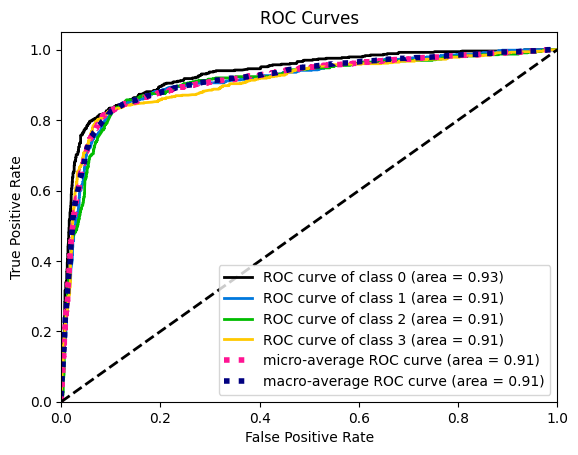

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

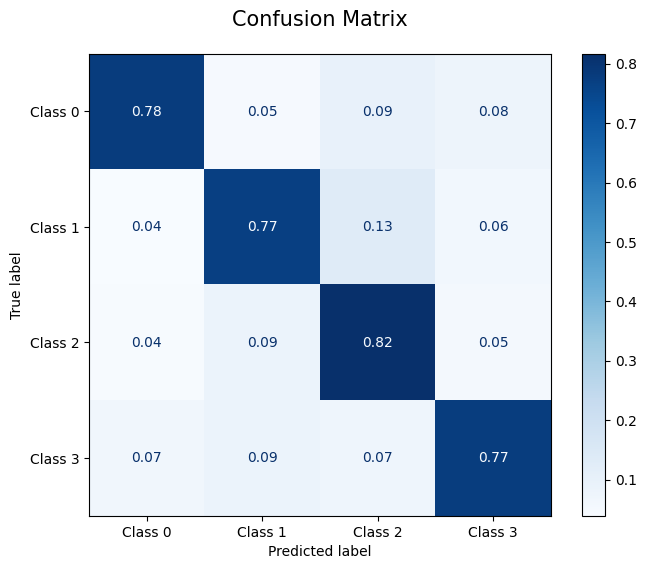

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### L2 Regularization

In [ ]:
from keras.regularizers import l2, l1

def build_L2_model():
    model = Sequential()

    n_feature = X_train_sel.shape[1]
    h_dim=100
    model.add(Dense(h_dim, activation='relu',
                    input_shape=(n_feature,), kernel_regularizer=l2(0.001)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(n_classes))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:
mc = ModelCheckpoint('best_model_L2.keras', monitor='val_accuracy', save_best_only=True)

L2_model = KerasClassifier(build_L2_model, callbacks=[es,mc])
L2_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2392 - loss: 1.5222 - val_accuracy: 0.2451 - val_loss: 1.4050
Epoch 2/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2304 - loss: 1.4049 - val_accuracy: 0.2443 - val_loss: 1.4047
Epoch 3/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2299 - loss: 1.4046 - val_accuracy: 0.2465 - val_loss: 1.4044
Epoch 4/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2302 - loss: 1.4042 - val_accuracy: 0.2465 - val_loss: 1.4040
Epoch 5/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2335 - loss: 1.4038 - val_accuracy: 0.2509 - val_loss: 1.4036
Epoch 6/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2344 - loss: 1.4034 - val_accuracy: 0.2487 - val_loss: 1.4031
Epoch 7/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2344 - loss: 1.4029 - val_accuracy: 0.2451 - val_loss: 1.4026
Epoch 8/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2346 - loss: 1.4023 - val_accuracy: 0.2524

KerasClassifier(
	model=<function build_L2_model at 0x7c0e16dd53a0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d6226d190>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0e16dbfb60>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

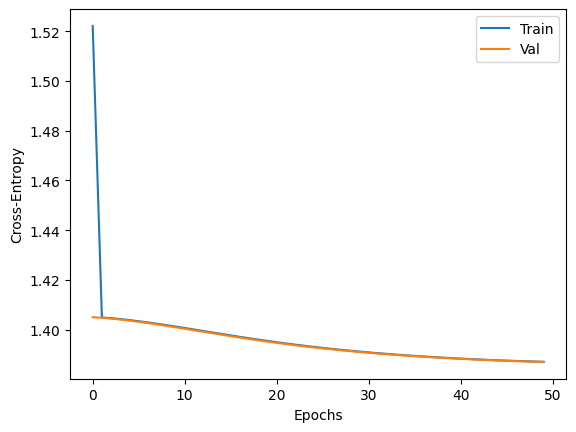

In [ ]:
history = L2_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

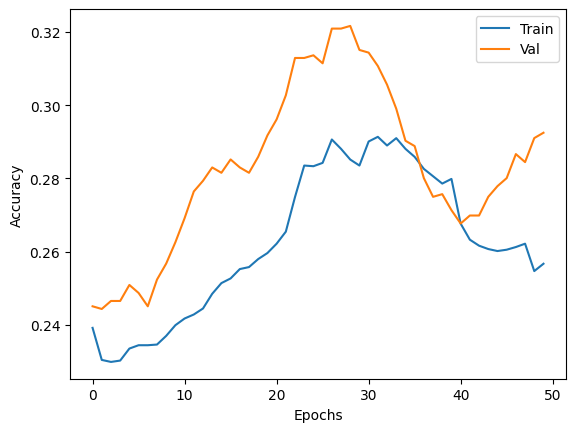

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Dropout

In [ ]:
from keras.layers import Dropout

def build_DROPOUT_model(meta):
    # define the model
    model = Sequential()

    n_feature = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    h_dim = 100
    model.add(Dense(h_dim, activation='relu', input_shape=(n_feature,)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(h_dim, activation='relu'))
    #linear activation
    model.add(Dense(n_classes, activation='softmax')) # Added activation for multiclass

    #compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

mc = ModelCheckpoint('best_model_DROPOUT.keras', monitor='val_accuracy', save_best_only=True)

DROPOUT_model = KerasClassifier(build_DROPOUT_model, callbacks=[es,mc])
DROPOUT_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6794 - loss: 0.9240 - val_accuracy: 0.8082 - val_loss: 0.6169
Epoch 2/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8241 - loss: 0.6316 - val_accuracy: 0.8133 - val_loss: 0.5938
Epoch 3/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8289 - loss: 0.5942 - val_accuracy: 0.8045 - val_loss: 0.5880
Epoch 4/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8289 - loss: 0.5754 - val_accuracy: 0.8074 - val_loss: 0.5842
Epoch 5/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8318 - loss: 0.5559 - val_accuracy: 0.8191 - val_loss: 0.5325
Epoch 6/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8336 - loss: 0.5451 - val_accuracy: 0.8060 - val_loss: 0.5759
Epoch 7/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8349 - loss: 0.5293 - val_accuracy: 0.8096 - val_loss: 0.5418
Epoch 8/500
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8336 - loss: 0.5297 - val_accuracy: 0.8133

KerasClassifier(
	model=<function build_DROPOUT_model at 0x7c0d5f21a340>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7c0d6226d190>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7c0d5f498e90>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

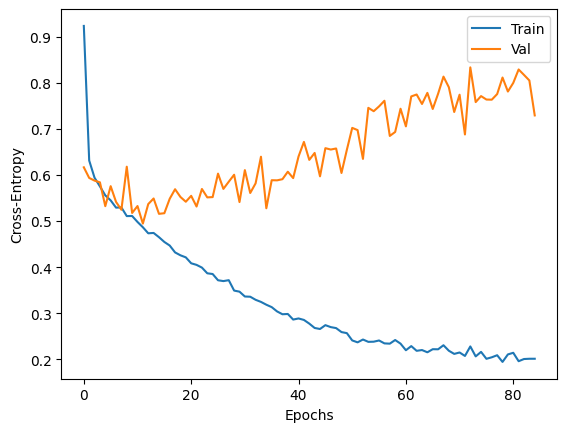

In [ ]:
history = DROPOUT_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

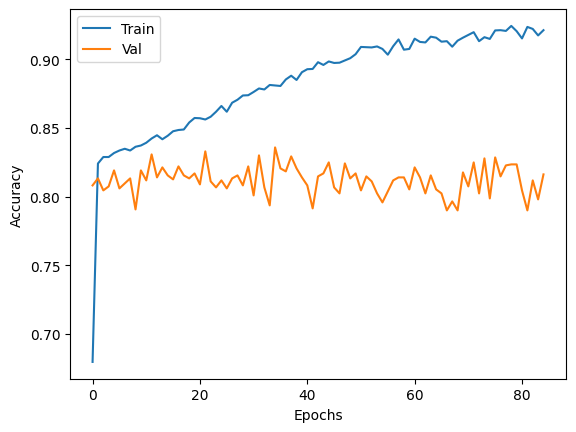

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Model Comparison

In [ ]:
# laod best models and test them
from keras.models import load_model

best_NOREG_model = load_model('best_model_NOREG.keras')
best_L2_model = load_model('best_model_L2.keras')
best_DROPOUT_model = load_model('best_model_DROPOUT.keras')

loss_NOREG, acc_NOREG = best_NOREG_model.evaluate(X_test_sel, y_test)
loss_L2, acc_L2 = best_L2_model.evaluate(X_test_sel, y_test)
loss_DROPOUT, acc_DROPOUT = best_DROPOUT_model.evaluate(X_test_sel, y_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7774 - loss: 0.9215
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2679 - loss: 1.3913
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8030 - loss: 0.8847


In [ ]:
print('Loss %f, Accuracy %f' % (loss_NOREG, acc_NOREG))
print('Loss %f, Accuracy %f' % (loss_L2, acc_L2))
print('Loss %f, Accuracy %f' % (loss_DROPOUT, acc_DROPOUT))

Loss 0.921478, Accuracy 0.777384
Loss 1.391306, Accuracy 0.267927
Loss 0.884711, Accuracy 0.802994
